# Customer Behaviour Clustering

**Question:** Can we discover stable, interpretable groups of credit-card customers from their behaviour alone?

**Dataset:** `data/CC GENERAL.csv` — approximately 9,000 customers, with balance, purchase, payment, cash-advance, and tenure features.  
**Methods:** K-Means, DBSCAN, and Gaussian Mixture Model (GMM).  
**Success criteria:** stable clusters, appropriate internal metrics, and profiles that can be explained from the original features.

## 1. Setup

**Purpose:** make every later experiment reproducible. The same seed lets us tell whether a changed result came from our decision or random initialisation.

**Decision menu — reproducibility**

- **Fixed seed (recommended):** reproducible comparisons; use this while learning and tuning.
- **Several fixed seeds:** later, test cluster stability instead of trusting one run.
- **No fixed seed:** only useful when intentionally measuring randomness; not suitable for our baseline.

Initial decision: use `42` as the shared baseline seed. We can later test whether the conclusion survives other seeds.

In [26]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")

print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"scikit-learn: {sklearn.__version__}")

pandas: 2.3.3
numpy: 2.5.3
scikit-learn: 1.9.1


## 2. Load and audit the data

**Purpose:** understand the raw data before changing it. We will make no imputation, outlier, scaling, or clustering decision in this section.

The audit answers: What does one row represent? Which columns are usable measurements? Are values missing or duplicated? Are feature scales wildly different?

In [27]:
DATA_PATH = Path("data/CC GENERAL.csv")
df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
display(df.head())

audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(),
}).sort_values("missing_pct", ascending=False)
display(audit)

print(f"Exact duplicate rows: {df.duplicated().sum():,}")
print(f"Duplicate customer IDs: {df['CUST_ID'].duplicated().sum():,}")
display(df.describe().T)

ID_COLUMN = "CUST_ID"
feature_columns = df.columns.drop(ID_COLUMN).tolist()
X_raw = df[feature_columns].copy()
print(f"Candidate feature matrix X_raw: {X_raw.shape}")

Rows: 8,950 | Columns: 18


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


,dtype,missing_count,missing_pct,n_unique
MINIMUM_PAYMENTS,float64,313,3.50,8636
CREDIT_LIMIT,float64,1,0.01,205
CUST_ID,object,0,0.00,8950
BALANCE,float64,0,0.00,8871
PRC_FULL_PAYMENT,float64,0,0.00,47
PAYMENTS,float64,0,0.00,8711
PURCHASES_TRX,int64,0,0.00,173
CASH_ADVANCE_TRX,int64,0,0.00,65
CASH_ADVANCE_FREQUENCY,float64,0,0.00,54
PURCHASES_INSTALLMENTS_FREQUENCY,float64,0,0.00,47


Exact duplicate rows: 0
Duplicate customer IDs: 0


,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


Candidate feature matrix X_raw: (8950, 17)


### Decision menu after the audit

We will make these choices only after seeing the audit output. Here are the standard defensible options and their trade-offs.

| Decision | Options we can test | What decides it |
| --- | --- | --- |
| Identifier (`CUST_ID`) | Drop from `X` **(default)**; retain only as a row label; use as a feature **(not valid)** | It is a unique code, so its numeric/text pattern says nothing about behaviour. |
| Exact duplicate rows | Keep; drop one copy; inspect before deciding | Duplicates may be data errors or genuine customers with identical recorded behaviour. |
| Missing values | Drop rows; drop feature; median imputation; mean imputation; constant value; KNN imputation; iterative/model-based imputation; add missingness indicators | Missingness rate, meaning of absence, and whether the choice changes cluster stability. |
| Skewed monetary values | Keep raw; `log1p`; robust transformation; quantile transformation; winsorise/cap extreme values | Histograms and whether a few extreme spenders dominate distance. |
| Feature scale | No scaling; StandardScaler; RobustScaler; MinMaxScaler; Normalizer; quantile scaling | K-Means, DBSCAN, and GMM all depend on scale; we will compare sensible choices later. |
| Feature set | All behavioural columns; remove redundant/correlated features; domain-selected subset; PCA components | Interpretability versus duplicated information and noise. |

**Not decided yet:** imputation, transformations, scaling, feature removal, and any clustering algorithm. Section 3 is where we choose and test them.

## 3. Prepare features

### 3.1 Missing values — baseline decision

**Decision:** use median imputation for every numeric behavioural feature.

We keep every customer row, replace each missing value with the median of its own column, and add no missingness indicators yet. This is the transparent baseline against which we will later test alternatives.

**Deliberately not used yet:** row deletion, mean imputation, constant-value imputation, KNN imputation, iterative/model-based imputation, and missingness indicators.

The next decision will be how to handle highly skewed monetary features before scaling.

In [28]:
from sklearn.impute import SimpleImputer

median_imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    median_imputer.fit_transform(X_raw),
    columns=feature_columns,
    index=X_raw.index,
)

imputation_summary = pd.DataFrame({
    "missing_before": X_raw.isna().sum(),
    "missing_after": X_imputed.isna().sum(),
}).query("missing_before > 0")

display(imputation_summary)
assert X_imputed.isna().sum().sum() == 0
print(f"Rows retained: {len(X_imputed):,}")
print("Median-imputation baseline complete.")

,missing_before,missing_after
CREDIT_LIMIT,1,0
MINIMUM_PAYMENTS,313,0


Rows retained: 8,950
Median-imputation baseline complete.


### 3.2 Skewed features — baseline decision

**Decision:** apply `log1p(x) = log(1 + x)` to non-negative monetary amounts and transaction counts.

`log1p` compresses the very large values without changing the order of customers, and it safely keeps zero as zero. We do **not** transform frequencies, `PRC_FULL_PAYMENT`, or `TENURE`: they are already bounded ratios or a short-duration count, so a logarithm would make their meaning less direct.

**Later alternatives to test:** no transformation; capping/winsorising extremes; RobustScaler without a log transform; quantile transformation.

This is still not scaling. The next decision will choose the scaler applied to all prepared features.

In [29]:
LOG1P_COLUMNS = [
    "BALANCE",
    "PURCHASES",
    "ONEOFF_PURCHASES",
    "INSTALLMENTS_PURCHASES",
    "CASH_ADVANCE",
    "CASH_ADVANCE_TRX",
    "PURCHASES_TRX",
    "CREDIT_LIMIT",
    "PAYMENTS",
    "MINIMUM_PAYMENTS",
]

assert (X_imputed[LOG1P_COLUMNS] >= 0).all().all(), "log1p requires non-negative values"

X_transformed = X_imputed.copy()
X_transformed[LOG1P_COLUMNS] = np.log1p(X_transformed[LOG1P_COLUMNS])

skewness_comparison = pd.DataFrame({
    "skew_before": X_imputed[LOG1P_COLUMNS].skew(),
    "skew_after_log1p": X_transformed[LOG1P_COLUMNS].skew(),
}).round(2)
display(skewness_comparison)

print("Applied log1p to monetary amounts and transaction counts only.")

,skew_before,skew_after_log1p
BALANCE,2.39,-0.86
PURCHASES,8.14,-0.76
ONEOFF_PURCHASES,10.05,0.19
INSTALLMENTS_PURCHASES,7.30,-0.02
CASH_ADVANCE,5.17,0.26
CASH_ADVANCE_TRX,5.72,0.94
PURCHASES_TRX,4.63,0.03
CREDIT_LIMIT,1.52,-0.10
PAYMENTS,5.91,-1.78
MINIMUM_PAYMENTS,13.85,0.27


Applied log1p to monetary amounts and transaction counts only.


### 3.3 Feature scaling — baseline decision

**Decision:** use `StandardScaler` after median imputation and selected `log1p` transformations.

It centres every feature at mean 0 and scales it to standard deviation 1. This gives each behavioural measurement comparable influence when distance-based algorithms calculate customer similarity.

**Later alternatives to test:** RobustScaler, MinMaxScaler, Normalizer, quantile transformation, or no scaling. They are separate experiments; they do not replace this baseline.

`X_prepared` is now the fixed input for our first clustering baseline.

In [30]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()
X_prepared = pd.DataFrame(
    standard_scaler.fit_transform(X_transformed),
    columns=feature_columns,
    index=X_transformed.index,
)

scaling_check = pd.DataFrame({
    "mean": X_prepared.mean(),
    "std": X_prepared.std(ddof=0),
}).round(3)
display(scaling_check)

print(f"Prepared matrix shape: {X_prepared.shape}")

,mean,std
BALANCE,0.0,1.0
BALANCE_FREQUENCY,0.0,1.0
PURCHASES,0.0,1.0
ONEOFF_PURCHASES,0.0,1.0
INSTALLMENTS_PURCHASES,0.0,1.0
CASH_ADVANCE,0.0,1.0
PURCHASES_FREQUENCY,-0.0,1.0
ONEOFF_PURCHASES_FREQUENCY,-0.0,1.0
PURCHASES_INSTALLMENTS_FREQUENCY,0.0,1.0
CASH_ADVANCE_FREQUENCY,0.0,1.0


Prepared matrix shape: (8950, 17)


## 4. Baseline

Run the simplest defensible version of the primary method. Record its parameters and metrics before tuning.

In [31]:
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score

# This is only a starting hypothesis, not the final chosen number of clusters.
BASELINE_K = 4

kmeans_baseline = KMeans(
    n_clusters=BASELINE_K,
    init="k-means++",
    n_init=20,
    max_iter=300, 
    random_state=RANDOM_STATE,
)

baseline_labels = kmeans_baseline.fit_predict(X_prepared)

baseline_metrics = {
    "k": BASELINE_K,
    "inertia": kmeans_baseline.inertia_,
    "silhouette_score": silhouette_score(X_prepared, baseline_labels),
    "davies_bouldin_score": davies_bouldin_score(X_prepared, baseline_labels),
}

print("Baseline metrics")
display(pd.Series(baseline_metrics).round(3))

cluster_sizes = (
    pd.Series(baseline_labels, name="cluster")
    .value_counts()
    .sort_index()
    .rename("customers")
    .to_frame()
)
cluster_sizes["share_pct"] = (cluster_sizes["customers"] / len(X_prepared) * 100).round(2)

print("Cluster sizes")
display(cluster_sizes)

# Use imputed original-scale values for interpretation.
# Do not interpret scaled/log-transformed values as money amounts.
customer_clusters = X_imputed.copy()
customer_clusters["cluster"] = baseline_labels

baseline_profile = customer_clusters.groupby("cluster").mean()
display(baseline_profile.round(2))

Baseline metrics


k                           4.000
inertia                 86547.005
silhouette_score            0.217
davies_bouldin_score        1.688
dtype: float64

Cluster sizes


,customers,share_pct
cluster,,
0,1570,17.54
1,2760,30.84
2,2580,28.83
3,2040,22.79


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
cluster,,,,,,,,,,,,,,,,,
0,213.58,0.53,351.39,271.26,80.50,113.63,0.25,0.11,0.13,0.02,0.36,3.93,3561.17,742.55,189.75,0.16,11.33
1,2460.81,0.94,103.32,79.46,23.90,2220.06,0.07,0.04,0.03,0.30,7.37,1.21,4364.17,1818.29,1123.10,0.03,11.39
2,2243.73,0.98,2604.15,1751.80,852.41,862.92,0.82,0.55,0.55,0.11,2.87,35.47,6393.23,2933.03,1090.31,0.17,11.81
3,532.39,0.93,697.61,67.39,631.11,112.15,0.81,0.04,0.76,0.02,0.38,15.02,2986.83,862.81,662.39,0.29,11.45


## 5. Model experiments

We compare three approaches on the same prepared 17-feature customer matrix. Each method answers a different question:

- **K-Means:** What small set of practical customer segments is most useful?
- **DBSCAN:** Which customers form dense regions, and which look unusual?
- **GMM:** Does a probability model describe overlapping customer behaviour better?

In [32]:
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score
from kneed import KneeLocator

K_VALUES = range(2, 11)
results = []

for k in K_VALUES:
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        max_iter=300,
        random_state=RANDOM_STATE,
    )

    labels = model.fit_predict(X_prepared)
    cluster_counts = pd.Series(labels).value_counts()

    results.append(
        {
            "k": k,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(X_prepared, labels),
            "davies_bouldin": davies_bouldin_score(X_prepared, labels),
            "smallest_cluster": cluster_counts.min(),
            "largest_cluster": cluster_counts.max(),
        }
    )

k_results = pd.DataFrame(results)

# Metric-based suggestion: highest silhouette score.
best_silhouette_k = int(
    k_results.loc[k_results["silhouette"].idxmax(), "k"]
)

# Elbow suggestion from the inertia curve.
knee = KneeLocator(
    k_results["k"],
    k_results["inertia"],
    curve="convex",
    direction="decreasing",
)
elbow_k = knee.knee

display(k_results.round(3))

print(f"Best K by silhouette score: {best_silhouette_k}")
print(f"Suggested K by inertia elbow: {elbow_k}")

,k,inertia,silhouette,davies_bouldin,smallest_cluster,largest_cluster
0,2,113331.595,0.252,1.506,3163,5787
1,3,95644.662,0.224,1.681,2871,3186
2,4,86547.005,0.217,1.688,1570,2760
3,5,77932.495,0.218,1.598,1394,2326
4,6,71656.377,0.217,1.466,1008,2191
5,7,67948.469,0.220,1.421,485,2053
6,8,64555.211,0.210,1.458,438,2007
7,9,61496.228,0.181,1.496,431,1301
8,10,58828.221,0.182,1.500,426,1283


Best K by silhouette score: 2
Suggested K by inertia elbow: 5


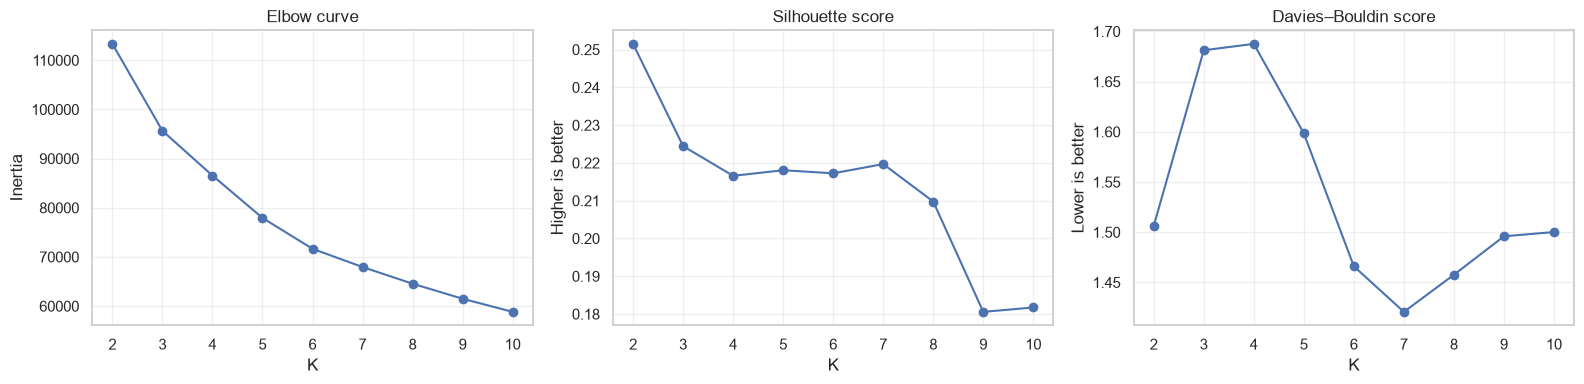

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(k_results["k"], k_results["inertia"], marker="o")
axes[0].set(title="Elbow curve", xlabel="K", ylabel="Inertia")

axes[1].plot(k_results["k"], k_results["silhouette"], marker="o")
axes[1].set(title="Silhouette score", xlabel="K", ylabel="Higher is better")

axes[2].plot(k_results["k"], k_results["davies_bouldin"], marker="o")
axes[2].set(title="Davies–Bouldin score", xlabel="K", ylabel="Lower is better")

for ax in axes:
    ax.set_xticks(list(K_VALUES))
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5.1 K-Means selection — conclusion

We tested `K = 2` to `10` while keeping preprocessing, K-Means++, `n_init=20`, and the random seed fixed.

- **`K=2` has the highest silhouette score (~0.251):** the clearest broad geometric separation.
- **The inertia curve has no sharp elbow:** improvements start becoming more gradual around `K=4–5`, but inertia alone cannot choose `K`.
- **`K=7` has the lowest Davies–Bouldin score (~1.42):** it makes clusters compact/separated by that measure, but its silhouette is lower than `K=2`.
- **`K=4` remains our working segmentation:** it produced four distinct and interpretable customer profiles: occasional users, cash-advance-heavy users, high-value active spenders, and instalment-focused users.

**Decision:** do not claim a universal metric winner. Treat `K=4` as the practical candidate and validate it against `K=2` and `K=7` using cluster sizes, profile usefulness, and stability across random seeds.

This completes the K-Means baseline and parameter sweep. The remaining K-Means validation is stability and candidate-profile comparison; then we will compare K-Means with DBSCAN and GMM.

### Candidate K validation — size and stability

We compare `K=2`, `K=4`, and `K=7`: the candidates suggested by our metrics and practical interpretation.

- **Cluster size:** reveals whether a candidate creates tiny, possibly accidental groups.
- **Stability:** refits K-Means from several random seeds. We use Adjusted Rand Index (ARI), which compares two partitions while ignoring arbitrary cluster-number names. `ARI = 1` means the partitions are identical; near `0` means little agreement.

This test changes only the random seed; preprocessing and `K` stay fixed.

In [34]:
from sklearn.metrics import adjusted_rand_score

CANDIDATE_KS = [2, 4, 7]
STABILITY_SEEDS = range(10)

candidate_labels = {}
validation_rows = []

for k in CANDIDATE_KS:
    # Fixed baseline result used for the profile and visualisation.
    baseline_model = KMeans(
        n_clusters=k, init="k-means++", n_init=20, max_iter=300, random_state=RANDOM_STATE
    )
    labels = baseline_model.fit_predict(X_prepared)
    candidate_labels[k] = labels

    cluster_counts = pd.Series(labels).value_counts()

    # Refit from other seeds; ARI does not care if cluster labels are renamed.
    seed_partitions = []
    for seed in STABILITY_SEEDS:
        model = KMeans(
            n_clusters=k, init="k-means++", n_init=20, max_iter=300, random_state=seed
        )
        seed_partitions.append(model.fit_predict(X_prepared))

    ari_scores = [
        adjusted_rand_score(seed_partitions[0], other_labels)
        for other_labels in seed_partitions[1:]
    ]

    validation_rows.append({
        "k": k,
        "smallest_cluster": cluster_counts.min(),
        "largest_cluster": cluster_counts.max(),
        "smallest_share_pct": round(cluster_counts.min() / len(X_prepared) * 100, 2),
        "mean_seed_ARI": round(np.mean(ari_scores), 3),
        "min_seed_ARI": round(np.min(ari_scores), 3),
    })

validation_results = pd.DataFrame(validation_rows).set_index("k")
display(validation_results)

for k in CANDIDATE_KS:
    sizes = pd.Series(candidate_labels[k], name="cluster").value_counts().sort_index().to_frame("customers")
    sizes["share_pct"] = (sizes["customers"] / len(X_prepared) * 100).round(2)
    print(f"K = {k}")
    display(sizes.T)

,smallest_cluster,largest_cluster,smallest_share_pct,mean_seed_ARI,min_seed_ARI
k,,,,,
2,3163,5787,35.34,1.000,1.000
4,1570,2760,17.54,0.998,0.993
7,485,2053,5.42,0.995,0.990


K = 2


cluster,0,1
customers,3163.00,5787.00
share_pct,35.34,64.66


K = 4


cluster,0,1,2,3
customers,1570.00,2760.00,2580.00,2040.00
share_pct,17.54,30.84,28.83,22.79


K = 7


cluster,0,1,2,3,4,5,6
customers,485.00,1304.00,2053.00,1399.00,1151.00,951.00,1607.00
share_pct,5.42,14.57,22.94,15.63,12.86,10.63,17.96


### Visual comparison — PCA projection of the candidate clusterings

PCA projects the same 17-dimensional prepared customer vectors onto two dimensions for our eyes. It does **not** replace the data used by K-Means.

If colours overlap, that does not automatically mean the clustering failed: information is lost when 17 dimensions are shown in two. Use this plot alongside the metrics, sizes, and customer profiles—not as the sole decision rule.

/Users/danylokuryliak/Desktop/Learn OS/ml-competitions/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/Users/danylokuryliak/Desktop/Learn OS/ml-competitions/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/Users/danylokuryliak/Desktop/Learn OS/ml-competitions/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


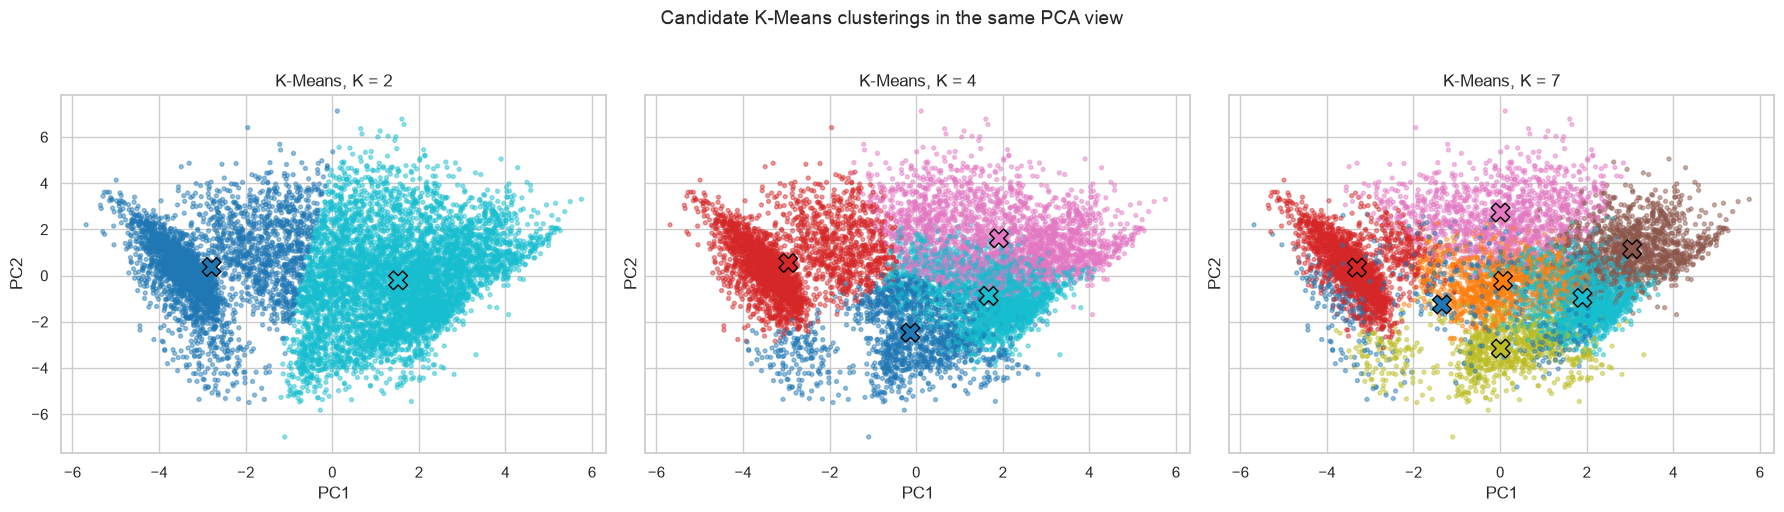

PCA variance shown in this 2D view: 55.8%


In [35]:
from sklearn.decomposition import PCA

pca_visual = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_visual = pca_visual.fit_transform(X_prepared)

fig, axes = plt.subplots(1, len(CANDIDATE_KS), figsize=(18, 5), sharex=True, sharey=True)

for ax, k in zip(axes, CANDIDATE_KS):
    labels = candidate_labels[k]
    ax.scatter(
        X_pca_visual[:, 0], X_pca_visual[:, 1],
        c=labels, cmap="tab10", s=8, alpha=0.45
    )

    # Transform centroids for display only.
    model = KMeans(
        n_clusters=k, init="k-means++", n_init=20, max_iter=300, random_state=RANDOM_STATE
    ).fit(X_prepared)
    centroid_pca = pca_visual.transform(model.cluster_centers_)
    ax.scatter(
        centroid_pca[:, 0], centroid_pca[:, 1],
        c=np.arange(k), cmap="tab10", marker="X", s=180, edgecolors="black", linewidths=1
    )

    ax.set(title=f"K-Means, K = {k}", xlabel="PC1", ylabel="PC2")

fig.suptitle("Candidate K-Means clusterings in the same PCA view", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

print(f"PCA variance shown in this 2D view: {pca_visual.explained_variance_ratio_.sum():.1%}")

### 5.2 Density-based clustering — DBSCAN

DBSCAN does not require us to choose a number of clusters. Instead, it defines a dense region using:

- `eps`: maximum neighbour distance;
- `min_samples`: neighbours needed to call a point a core point.

We use k-distance plots to propose `eps`, test a small grid, then inspect cluster sizes and noise. A label of `-1` means **noise / unusual under this density rule**, not automatically fraud or an error.

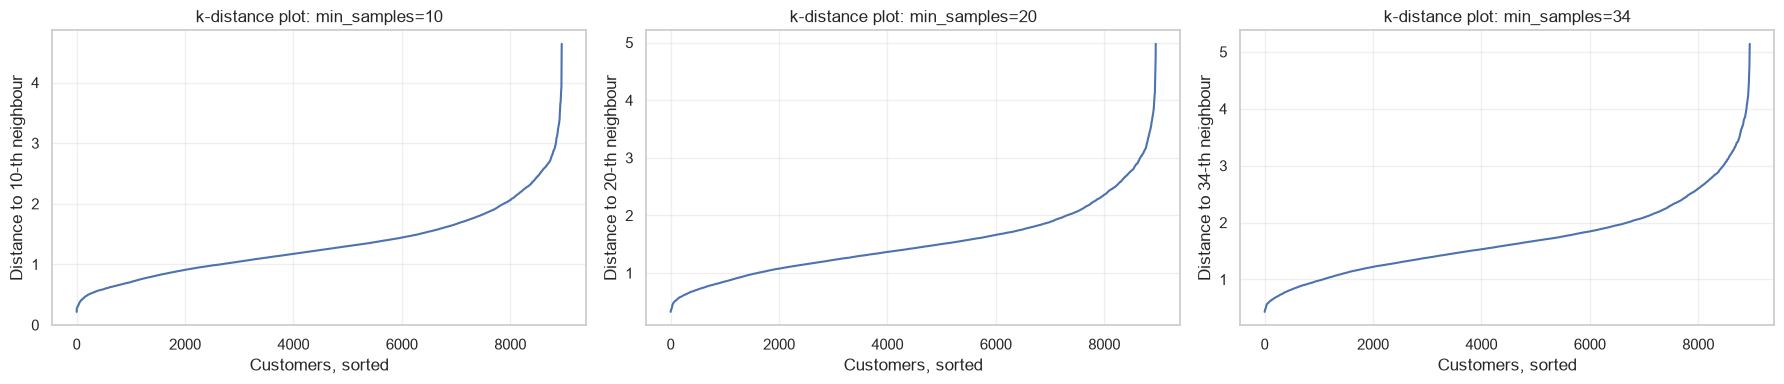


min_samples = 10


,eps_candidate
0.85,1.867807
0.90,2.093933
0.93,2.284058
0.95,2.449536



min_samples = 20


,eps_candidate
0.85,2.120538
0.90,2.397678
0.93,2.603414
0.95,2.776074



min_samples = 34


,eps_candidate
0.85,2.355508
0.90,2.636108
0.93,2.851610
0.95,3.060373


In [36]:
from sklearn.neighbors import NearestNeighbors

MIN_SAMPLES_OPTIONS = [10, 20, 34]
k_distances_by_min_samples = {}

fig, axes = plt.subplots(1, len(MIN_SAMPLES_OPTIONS), figsize=(18, 4))

for ax, min_samples in zip(axes, MIN_SAMPLES_OPTIONS):
    neighbors = NearestNeighbors(
        n_neighbors=min_samples,
        n_jobs=-1,
    )
    distances, _ = neighbors.fit(X_prepared).kneighbors(X_prepared)

    # Distance to each customer's min_samples-th nearest neighbour.
    k_distances = np.sort(distances[:, -1])
    k_distances_by_min_samples[min_samples] = k_distances

    ax.plot(k_distances)
    ax.set(
        title=f"k-distance plot: min_samples={min_samples}",
        xlabel="Customers, sorted",
        ylabel=f"Distance to {min_samples}-th neighbour",
    )
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

for min_samples, k_distances in k_distances_by_min_samples.items():
    print(f"\nmin_samples = {min_samples}")
    display(
        pd.Series(k_distances).quantile([0.85, 0.90, 0.93, 0.95]).to_frame("eps_candidate")
    )

In [37]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import davies_bouldin_score, silhouette_score

EPS_QUANTILES = [0.85, 0.90, 0.93, 0.95]
dbscan_results = []

for min_samples in MIN_SAMPLES_OPTIONS:
    eps_values = np.unique(
        np.quantile(k_distances_by_min_samples[min_samples], EPS_QUANTILES)
    )

    for eps in eps_values:
        model = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            n_jobs=-1,
        )

        labels = model.fit_predict(X_prepared)

        non_noise_mask = labels != -1
        non_noise_labels = labels[non_noise_mask]
        clusters = np.unique(non_noise_labels)
        n_clusters = len(clusters)
        noise_share_pct = (labels == -1).mean() * 100

        row = {
            "min_samples": min_samples,
            "eps": round(float(eps), 3),
            "n_clusters": n_clusters,
            "noise_share_pct": round(noise_share_pct, 2),
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "smallest_cluster": np.nan,
        }

        # Metrics only make sense when there are at least two non-noise clusters.
        if n_clusters >= 2:
            cluster_sizes = pd.Series(non_noise_labels).value_counts()

            row["smallest_cluster"] = cluster_sizes.min()
            row["silhouette"] = silhouette_score(
                X_prepared[non_noise_mask],
                non_noise_labels,
            )
            row["davies_bouldin"] = davies_bouldin_score(
                X_prepared[non_noise_mask],
                non_noise_labels,
            )

        dbscan_results.append(row)

dbscan_results = pd.DataFrame(dbscan_results)

display(
    dbscan_results.sort_values(
        by=["silhouette", "noise_share_pct"],
        ascending=[False, True],
        na_position="last",
    ).round(3)
)

,min_samples,eps,n_clusters,noise_share_pct,silhouette,davies_bouldin,smallest_cluster
4,20,2.121,2,5.82,0.279,0.917,57.0
8,34,2.356,2,5.50,0.279,0.877,49.0
2,10,2.284,2,2.08,0.197,1.065,15.0
10,34,2.852,2,1.34,0.131,1.225,17.0
0,10,1.868,5,7.39,0.101,1.026,10.0
1,10,2.094,5,3.93,0.072,1.008,7.0
11,34,3.060,1,0.73,NaN,NaN,NaN
7,20,2.776,1,0.97,NaN,NaN,NaN
3,10,2.450,1,1.25,NaN,NaN,NaN
6,20,2.603,1,1.53,NaN,NaN,NaN


### DBSCAN final inspection — dense groups and unusual customers

**Selected configuration:** `min_samples=20`, `eps=2.120538`. It has the strongest silhouette score in our tested grid, but its small second cluster means we interpret it as a density/outlier result, not our main customer segmentation.

We will inspect cluster sizes, core/border/noise counts, behavioural profiles, and a PCA visualisation.

In [38]:
SELECTED_MIN_SAMPLES = 20
SELECTED_EPS = 2.120538

dbscan_final = DBSCAN(
    eps=SELECTED_EPS,
    min_samples=SELECTED_MIN_SAMPLES,
    n_jobs=-1,
)
dbscan_labels = dbscan_final.fit_predict(X_prepared)

noise_mask = dbscan_labels == -1
non_noise_mask = ~noise_mask
non_noise_labels = dbscan_labels[non_noise_mask]
n_clusters = len(np.unique(non_noise_labels))

core_mask = np.zeros(len(dbscan_labels), dtype=bool)
core_mask[dbscan_final.core_sample_indices_] = True
border_mask = non_noise_mask & ~core_mask

print(f"Detected dense clusters: {n_clusters}")
print(f"Noise / unusual customers: {noise_mask.sum():,} ({noise_mask.mean():.2%})")
print(f"Core points: {core_mask.sum():,}")
print(f"Border points: {border_mask.sum():,}")

if n_clusters >= 2:
    print(f"Silhouette, excluding noise: {silhouette_score(X_prepared[non_noise_mask], non_noise_labels):.3f}")
    print(f"Davies-Bouldin, excluding noise: {davies_bouldin_score(X_prepared[non_noise_mask], non_noise_labels):.3f}")

Detected dense clusters: 2
Noise / unusual customers: 521 (5.82%)
Core points: 7,607
Border points: 822
Silhouette, excluding noise: 0.279
Davies-Bouldin, excluding noise: 0.917


In [39]:
dbscan_size_table = (
    pd.Series(dbscan_labels, name="cluster")
    .value_counts()
    .sort_index()
    .rename("customers")
    .to_frame()
)

dbscan_size_table.index = [
    "Noise (-1)" if cluster == -1 else f"Cluster {cluster}"
    for cluster in dbscan_size_table.index
]
dbscan_size_table["share_pct"] = (
    dbscan_size_table["customers"] / len(X_prepared) * 100
).round(2)

display(dbscan_size_table)

dbscan_group = pd.Series(dbscan_labels, index=X_imputed.index).map(
    lambda label: "Noise" if label == -1 else f"Cluster {label}"
)

dbscan_profiles = (
    X_imputed.assign(dbscan_group=dbscan_group)
    .groupby("dbscan_group")
    .mean()
)

display(dbscan_profiles.round(2))

,customers,share_pct
Noise (-1),521,5.82
Cluster 0,8372,93.54
Cluster 1,57,0.64


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
dbscan_group,,,,,,,,,,,,,,,,,
Cluster 0,1595.23,0.89,993.17,580.81,412.68,949.11,0.49,0.20,0.37,0.13,3.14,14.86,4503.30,1710.18,830.45,0.15,11.65
Cluster 1,3.69,0.10,180.81,30.02,150.79,0.00,0.35,0.01,0.32,0.00,0.00,5.25,3661.40,0.00,312.34,0.00,11.89
Noise,1241.05,0.70,1254.51,840.86,413.69,1564.16,0.44,0.26,0.25,0.22,5.37,13.38,4440.51,2291.78,1135.42,0.19,9.40


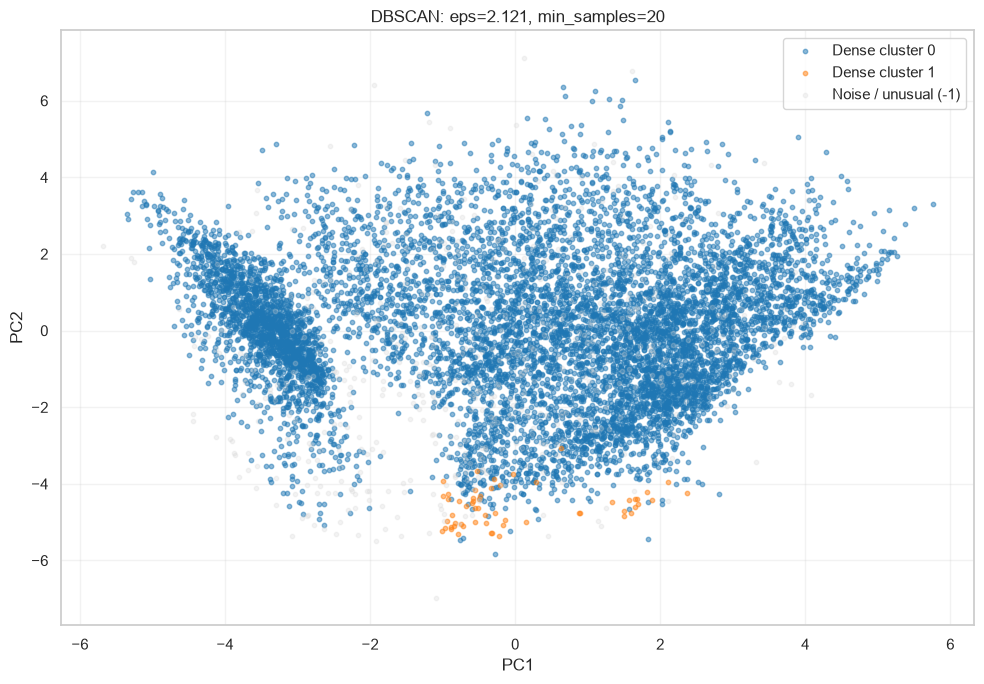

PCA variance shown in this 2D view: 55.8%


In [40]:
from sklearn.decomposition import PCA

pca_dbscan = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_dbscan = pca_dbscan.fit_transform(X_prepared)

plt.figure(figsize=(10, 7))

cluster_ids = sorted(set(dbscan_labels) - {-1})
colors = plt.get_cmap("tab10")

for color_index, cluster_id in enumerate(cluster_ids):
    mask = dbscan_labels == cluster_id
    plt.scatter(
        X_pca_dbscan[mask, 0], X_pca_dbscan[mask, 1],
        s=10, alpha=0.5, color=colors(color_index),
        label=f"Dense cluster {cluster_id}",
    )

plt.scatter(
    X_pca_dbscan[noise_mask, 0], X_pca_dbscan[noise_mask, 1],
    s=10, alpha=0.25, color="lightgray", label="Noise / unusual (-1)",
)

plt.title(f"DBSCAN: eps={SELECTED_EPS:.3f}, min_samples={SELECTED_MIN_SAMPLES}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"PCA variance shown in this 2D view: {pca_dbscan.explained_variance_ratio_.sum():.1%}")

## Gaussian Mixture Model (GMM)

**Question:** Do customer groups look like overlapping probability distributions rather than hard, equally shaped K-Means groups?

A GMM assumes the data was generated by several Gaussian components. Each component has a centre, a shape/spread, and a population share. Instead of only assigning a customer to one group, it estimates a probability for every component.

```text
K-Means: customer → one nearest centroid
GMM:     customer → [P(component 0), P(component 1), ...]
```

### Decision menu

| Choice | Options | Meaning |
| --- | --- | --- |
| Number of components | `2` to `10` | Equivalent to K in K-Means; selected mainly with BIC/AIC. |
| Covariance type | `full`, `tied`, `diag`, `spherical` | Controls whether components can be elliptical, share shape, assume independent features, or be round. |
| Initialisation | `kmeans`, `k-means++`, `random`, `random_from_data` | Starting position for the EM optimisation. |
| Repeated fits | `n_init` | Repeats the model from different starts and keeps the best likelihood. |
| Regularisation | `reg_covar` | Small value added to covariance matrices to avoid numerical failure. |

**Baseline decision:** compare four components with `covariance_type="full"`, `init_params="kmeans"`, `n_init=20`, and `reg_covar=1e-6`. `full` is a sensible baseline because customer behaviours can be correlated and elongated rather than round.

In [41]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import davies_bouldin_score, silhouette_score

GMM_BASELINE_COMPONENTS = 4

gmm_baseline = GaussianMixture(
    n_components=GMM_BASELINE_COMPONENTS,
    covariance_type="full",
    init_params="kmeans",
    n_init=20,
    max_iter=300,
    reg_covar=1e-6,
    random_state=RANDOM_STATE,
)

gmm_labels = gmm_baseline.fit_predict(X_prepared)
gmm_probabilities = gmm_baseline.predict_proba(X_prepared)
gmm_confidence = gmm_probabilities.max(axis=1)

gmm_baseline_metrics = pd.Series({
    "components": GMM_BASELINE_COMPONENTS,
    "BIC (lower is better)": gmm_baseline.bic(X_prepared),
    "AIC (lower is better)": gmm_baseline.aic(X_prepared),
    "silhouette (higher is better)": silhouette_score(X_prepared, gmm_labels),
    "Davies-Bouldin (lower is better)": davies_bouldin_score(X_prepared, gmm_labels),
    "mean assignment confidence": gmm_confidence.mean(),
})

display(gmm_baseline_metrics.round(3))

gmm_cluster_sizes = pd.Series(gmm_labels, name="component").value_counts().sort_index().to_frame("customers")
gmm_cluster_sizes["share_pct"] = (gmm_cluster_sizes["customers"] / len(X_prepared) * 100).round(2)
display(gmm_cluster_sizes)

components                               4.000
BIC (lower is better)              -160965.322
AIC (lower is better)              -165814.219
silhouette (higher is better)            0.176
Davies-Bouldin (lower is better)         1.899
mean assignment confidence               0.999
dtype: float64

,customers,share_pct
component,,
0,1614,18.03
1,2502,27.96
2,1789,19.99
3,3045,34.02


### GMM model selection — components and covariance type

We compare `2–10` components and four covariance assumptions. **BIC is the primary selection metric:** it rewards good probability fit but penalises unnecessary complexity. AIC is shown as a less strict second opinion.

```text
full      → every component has its own full covariance matrix; most flexible
tied      → all components share one covariance matrix
diag      → each component has feature-wise variances but no correlations
spherical → one variance per component; most restrictive
```

The broad search uses `n_init=5` to keep it practical. We will refit the selected configuration with `n_init=20` before drawing conclusions.

In [42]:
COMPONENT_VALUES = range(2, 11)
COVARIANCE_TYPES = ["full", "tied", "diag", "spherical"]
SEARCH_N_INIT = 5

gmm_search_results = []

for covariance_type in COVARIANCE_TYPES:
    for n_components in COMPONENT_VALUES:
        model = GaussianMixture(
            n_components=n_components,
            covariance_type=covariance_type,
            init_params="kmeans",
            n_init=SEARCH_N_INIT,
            max_iter=300,
            reg_covar=1e-6,
            random_state=RANDOM_STATE,
        )

        labels = model.fit_predict(X_prepared)
        probabilities = model.predict_proba(X_prepared)
        cluster_sizes = pd.Series(labels).value_counts()

        gmm_search_results.append({
            "covariance_type": covariance_type,
            "n_components": n_components,
            "BIC": model.bic(X_prepared),
            "AIC": model.aic(X_prepared),
            "silhouette": silhouette_score(X_prepared, labels),
            "davies_bouldin": davies_bouldin_score(X_prepared, labels),
            "mean_confidence": probabilities.max(axis=1).mean(),
            "smallest_component": cluster_sizes.min(),
            "converged": model.converged_,
            "iterations": model.n_iter_,
        })

gmm_search_results = pd.DataFrame(gmm_search_results)

display(
    gmm_search_results.sort_values("BIC")
    .head(12)
    .round(3)
)

best_bic_config = gmm_search_results.loc[gmm_search_results["BIC"].idxmin()]
best_aic_config = gmm_search_results.loc[gmm_search_results["AIC"].idxmin()]

print("Best BIC candidate:")
display(best_bic_config.to_frame("value"))

print("Best AIC candidate:")
display(best_aic_config.to_frame("value"))

,covariance_type,n_components,BIC,AIC,silhouette,davies_bouldin,mean_confidence,smallest_component,converged,iterations
8,full,10,-352430.282,-364563.172,0.137,2.598,0.999,39,True,31
7,full,9,-339525.935,-350444.826,0.144,2.329,1.000,306,True,28
6,full,8,-322300.382,-332005.274,0.145,2.361,1.000,473,True,28
5,full,7,-284363.482,-292854.374,0.163,2.339,1.000,195,True,19
4,full,6,-255534.470,-262811.364,0.170,2.289,1.000,513,True,37
26,diag,10,-237795.177,-240272.871,0.114,2.654,0.992,291,True,33
25,diag,9,-205558.833,-207788.047,0.136,2.564,0.998,308,True,25
24,diag,8,-196923.830,-198904.565,0.145,2.526,0.997,387,True,31
3,full,5,-189970.113,-196033.008,0.166,2.410,0.993,649,True,22
23,diag,7,-169422.129,-171154.384,0.158,2.520,1.000,609,True,28


Best BIC candidate:


,value
covariance_type,full
n_components,10
BIC,-352430.282218
AIC,-364563.171876
silhouette,0.136743
davies_bouldin,2.59772
mean_confidence,0.998834
smallest_component,39
converged,True
iterations,31


Best AIC candidate:


,value
covariance_type,full
n_components,10
BIC,-352430.282218
AIC,-364563.171876
silhouette,0.136743
davies_bouldin,2.59772
mean_confidence,0.998834
smallest_component,39
converged,True
iterations,31


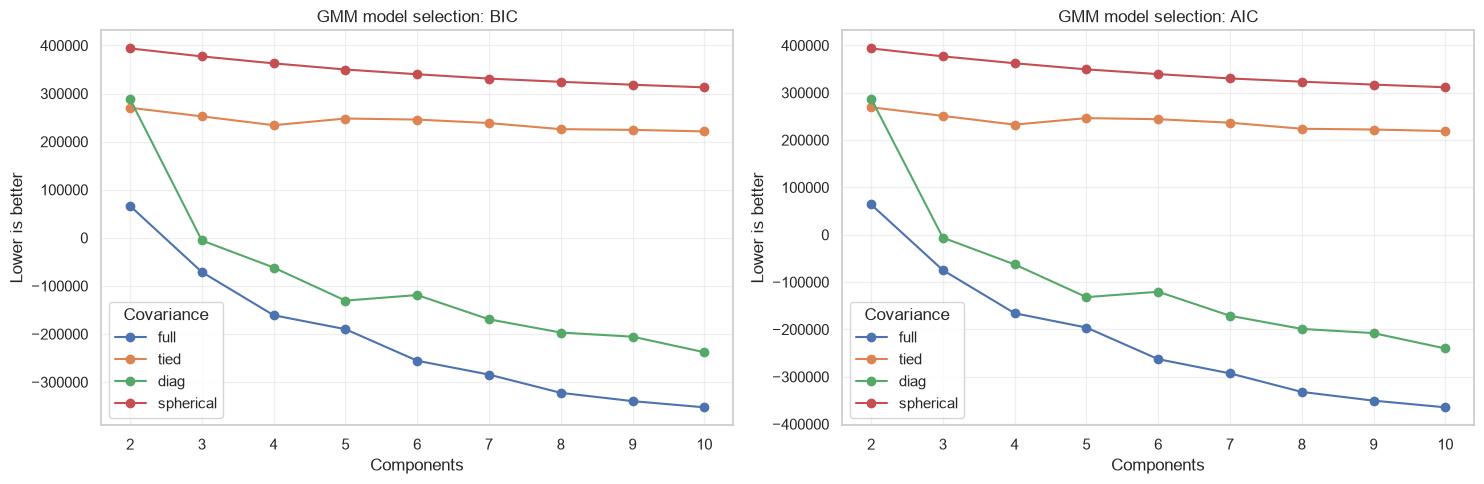

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

for covariance_type in COVARIANCE_TYPES:
    subset = gmm_search_results.query("covariance_type == @covariance_type")
    axes[0].plot(subset["n_components"], subset["BIC"], marker="o", label=covariance_type)
    axes[1].plot(subset["n_components"], subset["AIC"], marker="o", label=covariance_type)

axes[0].set(title="GMM model selection: BIC", xlabel="Components", ylabel="Lower is better")
axes[1].set(title="GMM model selection: AIC", xlabel="Components", ylabel="Lower is better")

for ax in axes:
    ax.set_xticks(list(COMPONENT_VALUES))
    ax.grid(alpha=0.3)
    ax.legend(title="Covariance")

plt.tight_layout()
plt.show()

### GMM extension — does full covariance reach a useful minimum?

The initial search chose 10 components only because 10 was the largest tested value. We now continue the **full-covariance** family to 15 components.

We will not choose the lowest BIC blindly. A useful candidate should have: a BIC minimum or clear plateau, no suspiciously tiny components, stable convergence, and profiles we can explain.

In [44]:
FULL_EXTENSION_COMPONENTS = range(11, 16)
gmm_full_extension_results = []

for n_components in FULL_EXTENSION_COMPONENTS:
    model = GaussianMixture(
        n_components=n_components,
        covariance_type="full",
        init_params="kmeans",
        n_init=SEARCH_N_INIT,
        max_iter=300,
        reg_covar=1e-6,
        random_state=RANDOM_STATE,
    )

    labels = model.fit_predict(X_prepared)
    probabilities = model.predict_proba(X_prepared)
    cluster_sizes = pd.Series(labels).value_counts()

    gmm_full_extension_results.append({
        "covariance_type": "full",
        "n_components": n_components,
        "BIC": model.bic(X_prepared),
        "AIC": model.aic(X_prepared),
        "silhouette": silhouette_score(X_prepared, labels),
        "davies_bouldin": davies_bouldin_score(X_prepared, labels),
        "mean_confidence": probabilities.max(axis=1).mean(),
        "smallest_component": cluster_sizes.min(),
        "converged": model.converged_,
        "iterations": model.n_iter_,
    })

gmm_full_extension_results = pd.DataFrame(gmm_full_extension_results)

gmm_full_results = pd.concat([
    gmm_search_results.query("covariance_type == 'full'"),
    gmm_full_extension_results,
], ignore_index=True).sort_values("n_components")

display(gmm_full_results.round(3))

best_full_config = gmm_full_results.loc[gmm_full_results["BIC"].idxmin()]
print("Best full-covariance candidate by BIC, within 2–15 components:")
display(best_full_config.to_frame("value"))

,covariance_type,n_components,BIC,AIC,silhouette,davies_bouldin,mean_confidence,smallest_component,converged,iterations
0,full,2,66352.473,63931.575,0.211,1.826,1.000,3912,True,11
1,full,3,-71190.155,-74825.053,0.167,1.769,1.000,1479,True,23
2,full,4,-160965.322,-165814.219,0.176,1.899,0.999,1614,True,24
3,full,5,-189970.113,-196033.008,0.166,2.410,0.993,649,True,22
4,full,6,-255534.470,-262811.364,0.170,2.289,1.000,513,True,37
5,full,7,-284363.482,-292854.374,0.163,2.339,1.000,195,True,19
6,full,8,-322300.382,-332005.274,0.145,2.361,1.000,473,True,28
7,full,9,-339525.935,-350444.826,0.144,2.329,1.000,306,True,28
8,full,10,-352430.282,-364563.172,0.137,2.598,0.999,39,True,31
9,full,11,-378185.208,-391532.096,0.127,2.526,0.999,255,True,45


Best full-covariance candidate by BIC, within 2–15 components:


,value
covariance_type,full
n_components,14
BIC,-417804.899494
AIC,-434793.784779
silhouette,0.111893
davies_bouldin,2.316286
mean_confidence,0.998661
smallest_component,66
converged,True
iterations,47


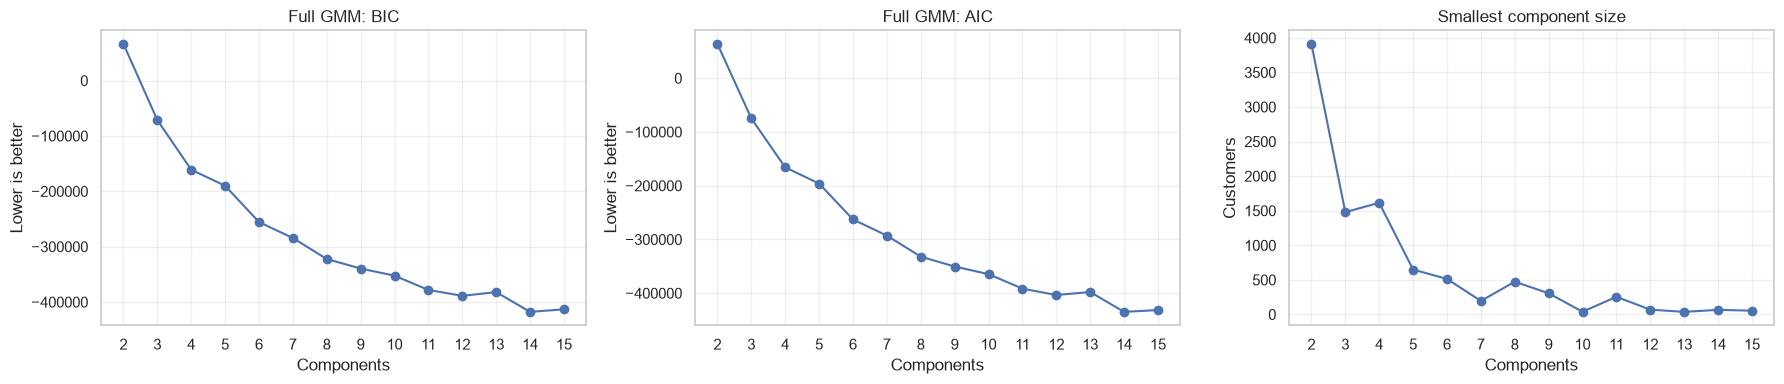

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(gmm_full_results["n_components"], gmm_full_results["BIC"], marker="o")
axes[0].set(title="Full GMM: BIC", xlabel="Components", ylabel="Lower is better")

axes[1].plot(gmm_full_results["n_components"], gmm_full_results["AIC"], marker="o")
axes[1].set(title="Full GMM: AIC", xlabel="Components", ylabel="Lower is better")

axes[2].plot(gmm_full_results["n_components"], gmm_full_results["smallest_component"], marker="o")
axes[2].set(title="Smallest component size", xlabel="Components", ylabel="Customers")

for ax in axes:
    ax.set_xticks(list(range(2, 16)))
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Final GMM density model — 14 full-covariance components

**Selection:** BIC and AIC both reach their lowest tested value at 14 components and worsen at 15. We refit this configuration with `n_init=20`.

This is the best **probability-density model** among the tested GMMs. It is not automatically our best customer segmentation: 14 components include small subpopulations and have weaker hard-cluster separation than K-Means `K=4`.

In [46]:
FINAL_GMM_COMPONENTS = 14

gmm_final = GaussianMixture(
    n_components=FINAL_GMM_COMPONENTS,
    covariance_type="full",
    init_params="kmeans",
    n_init=20,
    max_iter=300,
    reg_covar=1e-6,
    random_state=RANDOM_STATE,
)

gmm_final_labels = gmm_final.fit_predict(X_prepared)
gmm_final_probabilities = gmm_final.predict_proba(X_prepared)
gmm_final_confidence = gmm_final_probabilities.max(axis=1)

gmm_final_sizes = pd.Series(gmm_final_labels, name="component").value_counts().sort_index().to_frame("customers")
gmm_final_sizes["share_pct"] = (gmm_final_sizes["customers"] / len(X_prepared) * 100).round(2)

gmm_final_metrics = pd.Series({
    "BIC (lower is better)": gmm_final.bic(X_prepared),
    "AIC (lower is better)": gmm_final.aic(X_prepared),
    "silhouette (higher is better)": silhouette_score(X_prepared, gmm_final_labels),
    "Davies-Bouldin (lower is better)": davies_bouldin_score(X_prepared, gmm_final_labels),
    "mean assignment confidence": gmm_final_confidence.mean(),
    "minimum assignment confidence": gmm_final_confidence.min(),
    "converged": gmm_final.converged_,
    "iterations": gmm_final.n_iter_,
})

gmm_final_metrics_display = gmm_final_metrics.map(
    lambda value: round(value, 3)
    if isinstance(value, (float, int, np.floating, np.integer))
    and not isinstance(value, (bool, np.bool_))
    else value
)
display(gmm_final_metrics_display)
display(gmm_final_sizes)

BIC (lower is better)              -419279.841
AIC (lower is better)              -436268.726
silhouette (higher is better)            0.105
Davies-Bouldin (lower is better)         2.429
mean assignment confidence               0.999
minimum assignment confidence            0.562
converged                                 True
iterations                                  44
dtype: object

,customers,share_pct
component,,
0,760,8.49
1,1069,11.94
2,809,9.04
3,253,2.83
4,756,8.45
5,1523,17.02
6,1230,13.74
7,195,2.18
8,45,0.50


,highest component probability
count,8950.000000
mean,0.999194
std,0.012201
min,0.562233
1%,0.991935
5%,0.999804
10%,0.999967
25%,1.000000
50%,1.000000
75%,1.000000


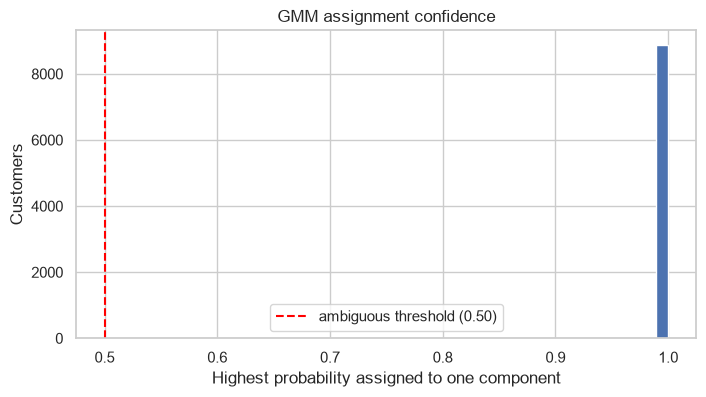

Customers with confidence below 0.80: 9
Customers with confidence below 0.50: 0


In [47]:
confidence_summary = pd.Series(gmm_final_confidence, name="highest component probability").describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)
display(confidence_summary.to_frame())

plt.figure(figsize=(8, 4))
plt.hist(gmm_final_confidence, bins=40, edgecolor="white")
plt.axvline(0.50, color="red", linestyle="--", label="ambiguous threshold (0.50)")
plt.title("GMM assignment confidence")
plt.xlabel("Highest probability assigned to one component")
plt.ylabel("Customers")
plt.legend()
plt.show()

print(f"Customers with confidence below 0.80: {(gmm_final_confidence < 0.80).sum():,}")
print(f"Customers with confidence below 0.50: {(gmm_final_confidence < 0.50).sum():,}")

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
component,,,,,,,,,,,,,,,,,
0,3241.74,1.00,1956.82,1161.00,795.89,2081.98,0.79,0.40,0.65,0.29,7.68,32.45,6112.50,3038.04,1365.41,0.03,12.00
1,762.61,0.77,883.04,883.04,0.00,0.00,0.36,0.36,0.00,0.00,0.00,7.73,4429.76,1202.37,485.74,0.14,11.56
2,1263.76,0.70,0.00,0.00,0.00,2231.93,0.00,0.00,0.00,0.25,5.53,0.00,3528.45,1864.86,517.38,0.09,10.28
3,137.38,0.81,409.36,0.00,409.36,0.00,0.79,0.00,0.68,0.00,0.00,7.82,1952.96,404.87,279.99,0.45,8.71
4,2169.43,1.00,2203.72,1304.72,899.20,0.00,0.81,0.44,0.66,0.00,0.00,35.64,5643.12,1813.82,1040.29,0.00,12.00
5,442.74,0.79,559.11,0.00,559.11,0.00,0.69,0.00,0.67,0.00,0.00,12.47,3297.58,788.18,760.97,0.28,12.00
6,2733.21,1.00,0.00,0.00,0.00,1832.59,0.00,0.00,0.00,0.29,6.81,0.00,4356.95,1517.73,1283.47,0.01,12.00
7,779.41,0.79,1923.34,1141.13,791.52,0.00,0.71,0.29,0.55,0.00,0.00,19.44,4953.33,2198.96,566.31,0.23,10.17
8,1002.14,0.53,471.67,329.78,141.90,970.53,0.33,0.11,0.25,0.09,2.64,5.24,3640.00,0.00,312.34,0.00,10.62


/Users/danylokuryliak/Desktop/Learn OS/ml-competitions/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


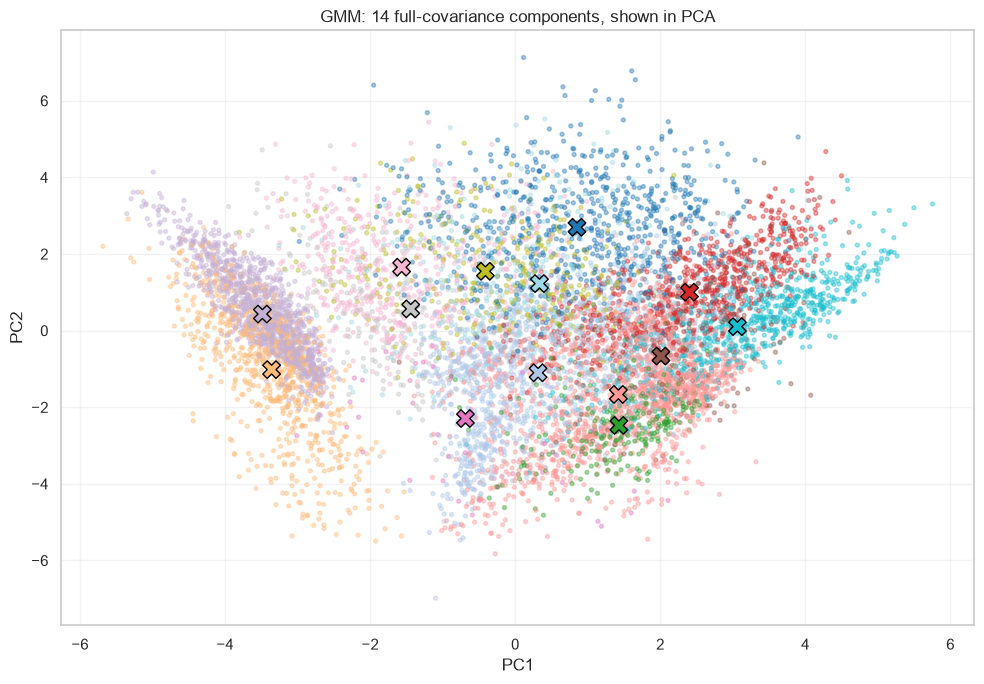

PCA variance shown in this 2D view: 55.8%


In [48]:
gmm_group = pd.Series(gmm_final_labels, index=X_imputed.index, name="component")
gmm_profiles = X_imputed.assign(component=gmm_group).groupby("component").mean()

display(gmm_profiles.round(2))

pca_gmm = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_gmm = pca_gmm.fit_transform(X_prepared)
means_pca_gmm = pca_gmm.transform(gmm_final.means_)

plt.figure(figsize=(10, 7))
plt.scatter(
    X_pca_gmm[:, 0], X_pca_gmm[:, 1],
    c=gmm_final_labels, cmap="tab20", s=8, alpha=0.40,
)
plt.scatter(
    means_pca_gmm[:, 0], means_pca_gmm[:, 1],
    c=np.arange(FINAL_GMM_COMPONENTS), cmap="tab20",
    marker="X", s=160, edgecolors="black", linewidths=1,
)
plt.title("GMM: 14 full-covariance components, shown in PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"PCA variance shown in this 2D view: {pca_gmm.explained_variance_ratio_.sum():.1%}")

## 6. Final comparison

The metrics are evidence, not an automatic winner. K-Means scores and DBSCAN scores describe hard cluster separation. GMM's BIC/AIC describe probability-density fit. We choose the method that best matches the goal: clear, usable customer segmentation.

In [49]:
dbscan_silhouette = silhouette_score(X_prepared[non_noise_mask], non_noise_labels)
dbscan_db = davies_bouldin_score(X_prepared[non_noise_mask], non_noise_labels)

final_comparison = pd.DataFrame([
    {
        "method": "K-Means",
        "configuration": "K=4, k-means++, n_init=20",
        "role": "Primary segmentation",
        "groups": 4,
        "silhouette": baseline_metrics["silhouette_score"],
        "davies_bouldin": baseline_metrics["davies_bouldin_score"],
        "key_result": "Four balanced, stable, interpretable profiles",
    },
    {
        "method": "DBSCAN",
        "configuration": "eps=2.120538, min_samples=20",
        "role": "Density / unusual-customer check",
        "groups": n_clusters,
        "silhouette": dbscan_silhouette,
        "davies_bouldin": dbscan_db,
        "key_result": f"{noise_mask.mean():.2%} labelled noise; one group has only 57 customers",
    },
    {
        "method": "GMM",
        "configuration": "14 components, full covariance",
        "role": "Probability-density model",
        "groups": FINAL_GMM_COMPONENTS,
        "silhouette": gmm_final_metrics["silhouette (higher is better)"],
        "davies_bouldin": gmm_final_metrics["Davies-Bouldin (lower is better)"],
        "key_result": "Best BIC/AIC tested, but many small components",
    },
])

numeric_columns = ["silhouette", "davies_bouldin"]
final_comparison[numeric_columns] = final_comparison[numeric_columns].round(3)
display(final_comparison)

,method,configuration,role,groups,silhouette,davies_bouldin,key_result
0,K-Means,"K=4, k-means++, n_init=20",Primary segmentation,4,0.217,1.688,"Four balanced, stable, interpretable profiles"
1,DBSCAN,"eps=2.120538, min_samples=20",Density / unusual-customer check,2,0.279,0.917,5.82% labelled noise; one group has only 57 cu...
2,GMM,"14 components, full covariance",Probability-density model,14,0.105,2.429,"Best BIC/AIC tested, but many small components"


## 7. Conclusions and limitations

### Final conclusion

Use **K-Means with K=4** as the final customer segmentation. It gives four reasonably balanced groups, remains almost unchanged across random initialisations, and is simple to explain:

1. occasional / low-activity customers;
2. cash-advance-heavy, purchase-light customers;
3. high-value, active purchasers;
4. installment-focused purchasers.

K=2 is the clearest broad split, but K=4 gives more actionable detail. DBSCAN is useful for checking dense regions and unusual customers, but it gives one dominant cluster and a tiny niche. GMM is the best tested probability-density model, but its 14 components are too detailed for a simple segmentation.

### Important limitations

- The data has no target or ground-truth customer types, so these groups are hypotheses, not proven labels.
- PCA plots show only 55.8% of variation. They are visual aids; all models were fitted on all 17 prepared features.
- Median imputation can affect small groups, especially where `MINIMUM_PAYMENTS` was missing. Check missingness before acting on a niche group.
- K-Means prefers compact, roughly spherical groups; DBSCAN depends strongly on `eps` and `min_samples`; GMM depends on its distribution assumptions.
- Before business use, check whether the profiles stay stable on newer data and ask a domain expert whether they are useful.